In [19]:
from ihp import PDK
from ihp.cells.resistors import rhigh
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

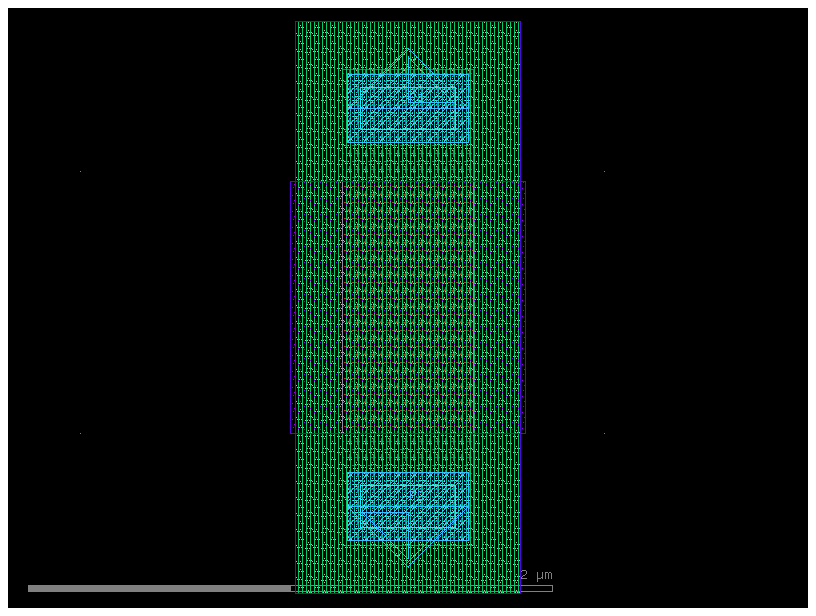

In [20]:
c = rhigh()

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [ ]:
# Checking the port layers.
cc.ports

["Port(self.name='P1', self.width=460, trans=r90 *1 0.25,1.24, layer=Metal1pin (8/2), port_type=electrical)", "Port(self.name='P2', self.width=460, trans=r270 *1 0.25,-0.28, layer=Metal1pin (8/2), port_type=electrical)"]

In [22]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-rhigh")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=5.0)

sim.add_port("P1",layer="metal1")
sim.add_port("P2",layer="metal1")

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [ ]:
# TODO: investigate why Z dimension is much larger than expected.
sim.mesh(preset="graded",margin=1.0,refined_mesh_size=0.2)

Mesh Summary
Dimensions: 2.9 x 4.2 x 23.3 µm
Nodes:      607
Elements:   4,194
Tetrahedra: 2,906
Edge length: 0.05 - 5.35 µm
Quality:    0.610 (min: 0.037)
SICN:       0.652 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (15):
  - poly_xy [4]
  - poly_z [5]
  - heatres_xy [6]
  - heatres_z [7]
  - metal1_xy [8]
  - metal1_z [9]
  - polyres_xy [10]
  - polyres_z [11]
  - P1 [12]
  - P2 [13]
  - SiO2__None [14]
  - SiO2__passive [15]
  - passive__None [16]
  - air__passive [17]
  - air__None [18]
----------------------------------------
Mesh:   runs/palace-sim-rhigh/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:29:57.646 ( 168.982s) [    771F4C690080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:29:57.655 ( 168.992s) [    771F4C690080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:29:57.710 ( 169.046s) [    771F4C690080]vt

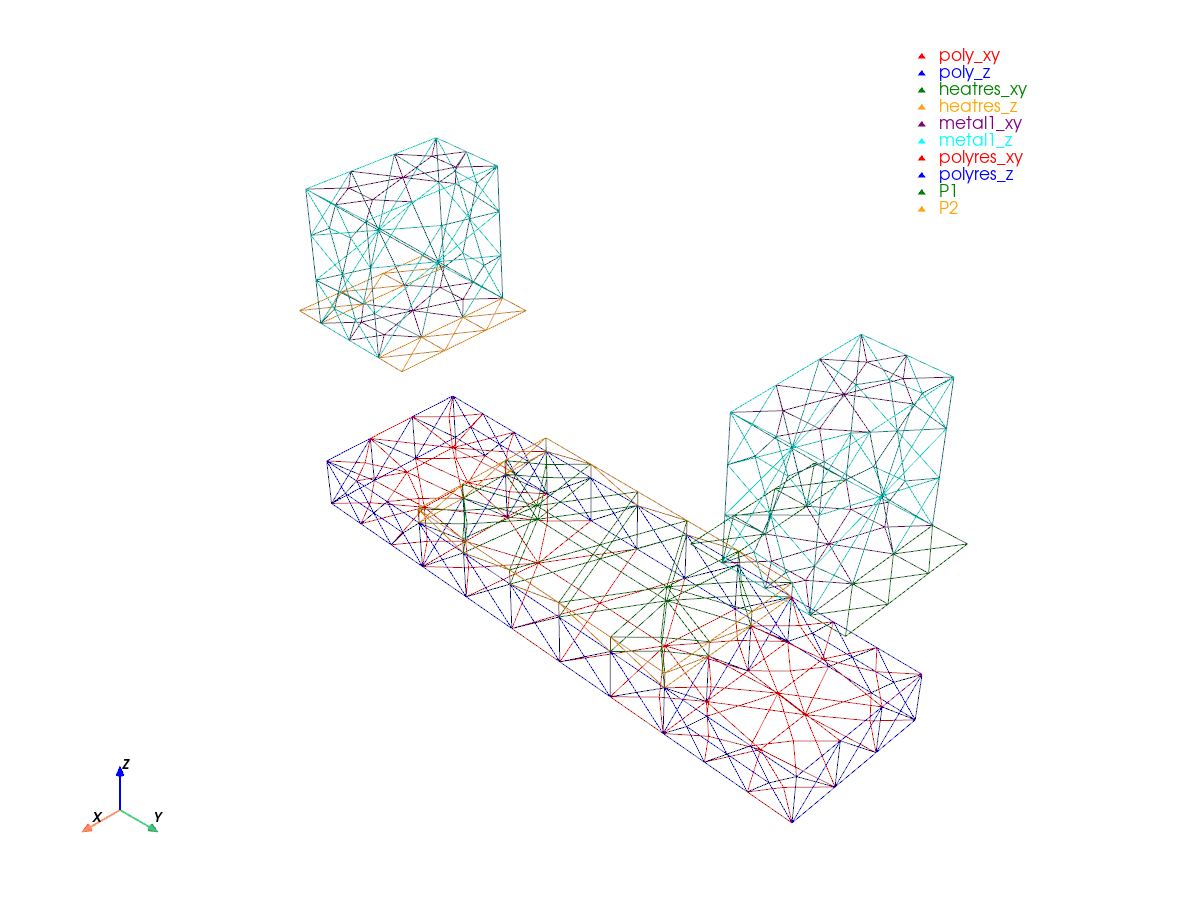

In [24]:
sim.plot_mesh(show_groups=["metal","P","poly","heatres"],interactive=False)

In [25]:
results = sim.run(parent_dir="runs")

  palace-fd90dc38  completed  0m 18s
Extracting results.tar.gz...
Downloaded 6 files to runs/sim-data-palace-fd90dc38


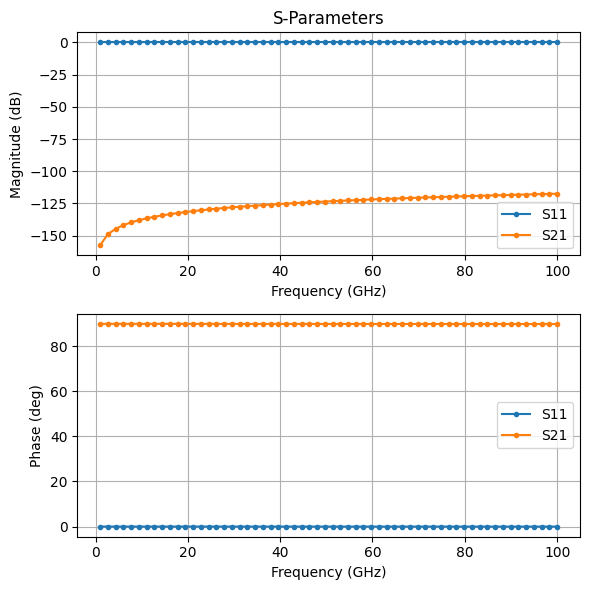

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()

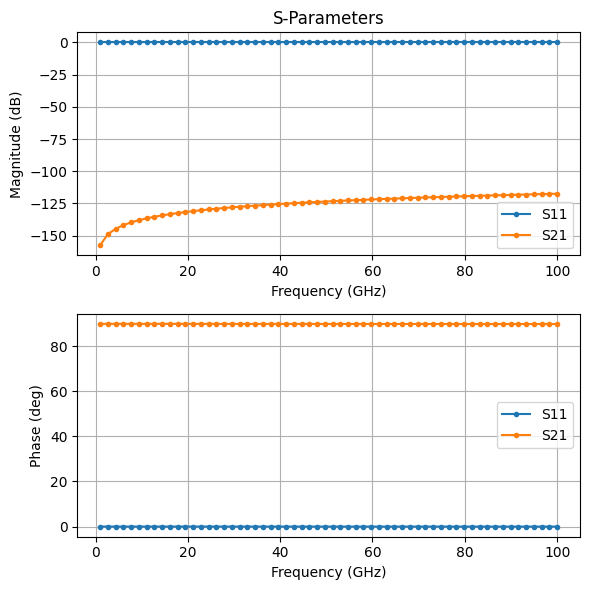

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()